In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/tb0329.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/tb0139.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/CHNCXR_0572_1.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/CHNCXR_0547_1.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/tb0733.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/CHNCXR_0629_1.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/CHNCXR_0618_1.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen/TB/tb0100.png
/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenz

In [ ]:
# Cell 1: Imports & Device Setup
!pip install torchxrayvision --quiet
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchxrayvision as xrv

import cv2
import numpy as np
import os
from glob import glob
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


In [ ]:
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np
import os
from glob import glob
import torchvision.transforms as transforms

class TB_Dataset(Dataset):
    def __init__(self, folder_path, augment=False):
        self.images = []
        self.labels = []
        self.augment = augment
        for label, cls in enumerate(["Normal", "TB"]):  # folder names must match exactly
            cls_folder = os.path.join(folder_path, cls)
            for img_path in glob(os.path.join(cls_folder, "*")):
                self.images.append(img_path)
                self.labels.append(label)

        # Define augmentation transforms
        self.transform = transforms.Compose([
            transforms.RandomHorizontalFlip() if augment else transforms.Lambda(lambda x: x),
            transforms.RandomRotation(degrees=10) if augment else transforms.Lambda(lambda x: x)
        ])

        print(f"Found {len(self.images)} images in {folder_path}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        img = clahe.apply(img)
        img = cv2.resize(img, (224, 224))
        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, axis=0)
        img_tensor = torch.tensor(img, dtype=torch.float32)
        img_tensor = self.transform(img_tensor)
        label = self.labels[idx]
        return img_tensor, label


In [12]:
# Cell 2: Dataset Class
class TB_Dataset(Dataset):
    def __init__(self, folder_path, augment=False):
        self.images = []
        self.labels = []
        self.augment = augment
        
        for label, cls in enumerate(["Normal", "TB"]):  # folder names must match exactly
            cls_folder = os.path.join(folder_path, cls)
            for img_path in glob(os.path.join(cls_folder, "*")):
                self.images.append(img_path)
                self.labels.append(label)
        
        # Transform for augmentation
        self.transform = transforms.Compose([
            transforms.RandomHorizontalFlip() if augment else transforms.Lambda(lambda x: x),
            transforms.RandomRotation(degrees=10) if augment else transforms.Lambda(lambda x: x)
        ])
        print(f"Found {len(self.images)} images in {folder_path}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        # CLAHE
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        img = clahe.apply(img)
        
        # Resize to 224x224 for DenseNet
        img = cv2.resize(img, (224, 224))
        
        img = img.astype(np.float32) / 255.0
        img = np.expand_dims(img, axis=0)  # [1,H,W]
        img_tensor = torch.tensor(img, dtype=torch.float32)
        
        img_tensor = self.transform(img_tensor)
        label = self.labels[idx]
        return img_tensor, label


In [13]:
# Cell 3: Load Dataset
dataset = TB_Dataset("/kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen", augment=True)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)


Found 2388 images in /kaggle/input/combine-tbx11k-montgomery-and-shenzhen-tb-only/combine_TBX11K_montgomery_shenzhen


In [14]:
# Cell 4: Model Setup (fixed for binary TB)
model = xrv.models.DenseNet(weights="densenet121-res224-all")  # pretrained
model = model.to(device)

# Remove op_threshs to avoid internal 18-class normalization
model.op_threshs = None

# Replace classifier for binary TB classification
model.classifier = nn.Sequential(
    nn.Linear(model.classifier.in_features, 1),
    nn.Sigmoid()
).to(device)

# Loss & Optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-4)


In [15]:
# Cell 5: Training Loop (with accuracy and val loss added)
from sklearn.metrics import roc_auc_score, recall_score, accuracy_score

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.float().unsqueeze(1).to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
        # ---- Train Accuracy ----
        preds = (outputs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    avg_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    # ---- Validation ----
    model.eval()
    val_preds = []
    val_targets = []
    val_losses = []

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.float().unsqueeze(1).to(device)
            outputs = model(imgs)
            val_losses.append(criterion(outputs, labels).item())
            val_preds.extend(outputs.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())
    
    val_loss = sum(val_losses) / len(val_losses)
    val_preds_bin = [1 if p > 0.5 else 0 for p in val_preds]

    val_accuracy = accuracy_score(val_targets, val_preds_bin)
    auc = roc_auc_score(val_targets, val_preds)
    sensitivity = recall_score(val_targets, val_preds_bin)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Loss: {avg_loss:.4f} | Acc: {train_accuracy:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f} | "
          f"Val AUC: {auc:.4f} | Sensitivity: {sensitivity:.4f}")


Epoch 1/20 | Loss: 0.6763 | Acc: 0.6178 | Val Loss: 0.6983 | Val Acc: 0.5335 | Val AUC: 0.5100 | Sensitivity: 0.0000
Epoch 2/20 | Loss: 0.6477 | Acc: 0.7257 | Val Loss: 0.6471 | Val Acc: 0.7008 | Val AUC: 0.7749 | Sensitivity: 0.5291
Epoch 3/20 | Loss: 0.6296 | Acc: 0.7257 | Val Loss: 0.6269 | Val Acc: 0.7134 | Val AUC: 0.8072 | Sensitivity: 0.5202
Epoch 4/20 | Loss: 0.6113 | Acc: 0.7539 | Val Loss: 0.6119 | Val Acc: 0.6925 | Val AUC: 0.7979 | Sensitivity: 0.5022
Epoch 5/20 | Loss: 0.5911 | Acc: 0.7743 | Val Loss: 0.5974 | Val Acc: 0.7385 | Val AUC: 0.8162 | Sensitivity: 0.6726
Epoch 6/20 | Loss: 0.5757 | Acc: 0.7801 | Val Loss: 0.5869 | Val Acc: 0.7510 | Val AUC: 0.8222 | Sensitivity: 0.6951
Epoch 7/20 | Loss: 0.5671 | Acc: 0.7785 | Val Loss: 0.5844 | Val Acc: 0.7218 | Val AUC: 0.8073 | Sensitivity: 0.6592
Epoch 8/20 | Loss: 0.5490 | Acc: 0.7869 | Val Loss: 0.5734 | Val Acc: 0.7406 | Val AUC: 0.8181 | Sensitivity: 0.6951
Epoch 9/20 | Loss: 0.5442 | Acc: 0.7916 | Val Loss: 0.5560 | Val

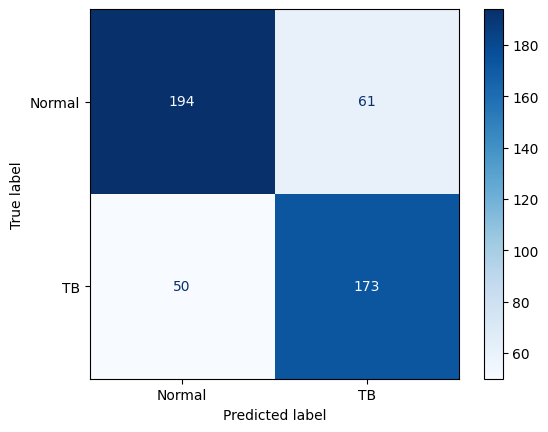

In [16]:
# Cell 6: Confusion Matrix
cm = confusion_matrix(val_targets, val_preds_bin)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal","TB"])
disp.plot(cmap=plt.cm.Blues)
plt.show()


In [25]:
def grad_cam(model, img_tensor, class_index=None):
    model.eval()
    img_tensor = img_tensor.to(device).unsqueeze(0)

    target_layer = model.features.denseblock4  # Last conv block in DenseNet

    fmap = []
    grads = []

    def forward_hook(module, input, output):
        fmap.append(output)

    def backward_hook(module, grad_in, grad_out):
        grads.append(grad_out[0])

    f_handle = target_layer.register_forward_hook(forward_hook)
    b_handle = target_layer.register_backward_hook(backward_hook)

    output = model(img_tensor)

    score = output[0, 0]  # Binary output shape [1]

    model.zero_grad()
    score.backward()

    f_handle.remove()
    b_handle.remove()

    gradient = grads[0].cpu().data.numpy()[0]
    feature = fmap[0].cpu().data.numpy()[0]

    weights = np.mean(gradient, axis=(1, 2))
    cam = np.zeros(feature.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * feature[i]

    cam = np.maximum(cam, 0)
    cam /= (cam.max() + 1e-8)
    cam = cv2.resize(cam, (224, 224))

    # ✅ Correct grayscale visualization
    img = img_tensor.cpu().squeeze().numpy()   # (H, W)
    img = (img - img.min()) / (img.max() + 1e-8)

    plt.figure(figsize=(6,6))
    plt.imshow(img, cmap='gray')
    plt.imshow(cam, cmap='jet', alpha=0.45)
    plt.title("Grad-CAM (TB Region Highlighted)")
    plt.axis("off")
    plt.show()


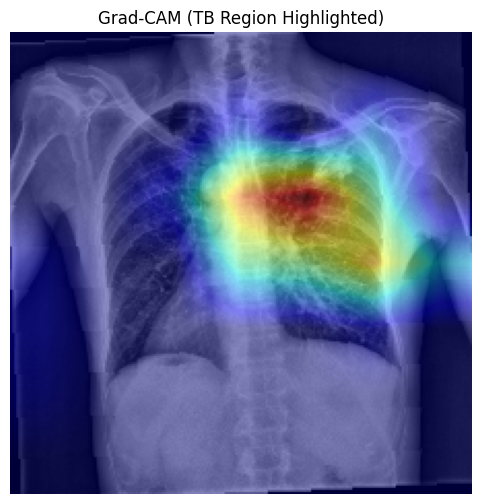

In [26]:
img, label = next(iter(val_loader))
grad_cam(model, img[0])


In [27]:
def grad_cam(model, img_tensor, class_index=None):
    model.eval()
    img_tensor = img_tensor.to(device).unsqueeze(0)

    target_layer = model.features.denseblock4  # Last conv block in DenseNet

    fmap = []
    grads = []

    def forward_hook(module, input, output):
        fmap.append(output)

    def backward_hook(module, grad_in, grad_out):
        grads.append(grad_out[0])

    f_handle = target_layer.register_forward_hook(forward_hook)
    b_handle = target_layer.register_backward_hook(backward_hook)

    output = model(img_tensor)

    score = output[0, 0]

    model.zero_grad()
    score.backward()

    f_handle.remove()
    b_handle.remove()

    gradient = grads[0].cpu().data.numpy()[0]
    feature = fmap[0].cpu().data.numpy()[0]

    weights = np.mean(gradient, axis=(1, 2))
    cam = np.zeros(feature.shape[1:], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * feature[i]

    cam = np.maximum(cam, 0)
    cam /= (cam.max() + 1e-8)
    cam = cv2.resize(cam, (224, 224))

    # ✅ Convert grayscale image
    img = img_tensor.cpu().squeeze().numpy()
    img = (img - img.min()) / (img.max() + 1e-8)

    # ✅ Prediction Label
    pred_label = "TB" if score.item() > 0.5 else "Normal"
    pred_prob = score.item()

    # ✅ Display
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(img, cmap='gray')
    ax[0].set_title(f"Original\nPrediction: {pred_label} ({pred_prob:.2f})")
    ax[0].axis("off")

    ax[1].imshow(img, cmap='gray')
    ax[1].imshow(cam, cmap='jet', alpha=0.45)
    ax[1].set_title("Grad-CAM Heatmap")
    ax[1].axis("off")

    plt.show()


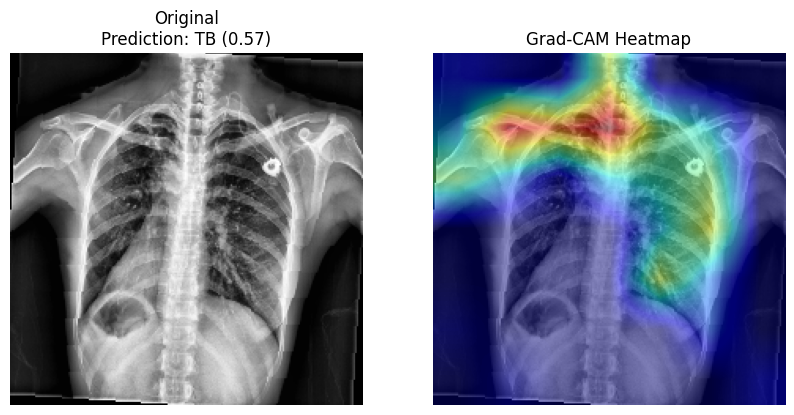

In [33]:
img, label = next(iter(val_loader))
grad_cam(model, img[4])
